# 01 - Exploratory Data Analysis (EDA)

Section **3.2 Exploratory Data Analysis (EDA)** of the report.

## Brief

Descriptive statistics, key visualizations (histograms, correlations, class distribution) and identification of issues such as class imbalance, outliers, or missing values.

- Descriptive statistics (`describe`, dtypes, counts).
- Visualizations: histograms, boxplots, correlations, class distribution.
- Detect class imbalance, outliers, missing values.

In [17]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from data_profiling import ProfileReport
from pathlib import Path
from scipy import stats

RAW = Path("../data/raw")
REPORTS = Path("../reports")

## Data loading

In [18]:
df = pd.read_csv(RAW / "winemag-data-130k-v2.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (129971, 13)


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## Profiling report

Full automated EDA via `fg-data-profiling`. The report is also exported as a standalone HTML file to `reports/`.

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:04<00:00,  3.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

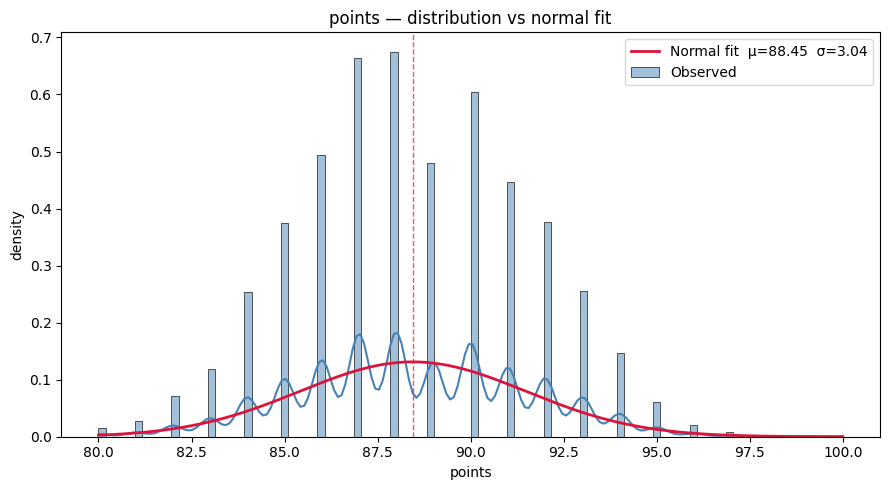

In [19]:
profile = ProfileReport(
    df,
    title="Wine Reviews — EDA",
    explorative=True,
)
profile.to_notebook_iframe()

In [20]:
profile.to_file(REPORTS / "01-eda-profile.html")
print("Report saved to reports/01-eda-profile.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved to reports/01-eda-profile.html


## Distribution analysis

Statistical moments and distribution plots for the two numeric columns.

=== points — moments ===
  Mean:     88.4471
  SDEV:     3.0397
  Skewness: 0.0459
  Kurtosis: -0.2960  (excess; normal = 0)


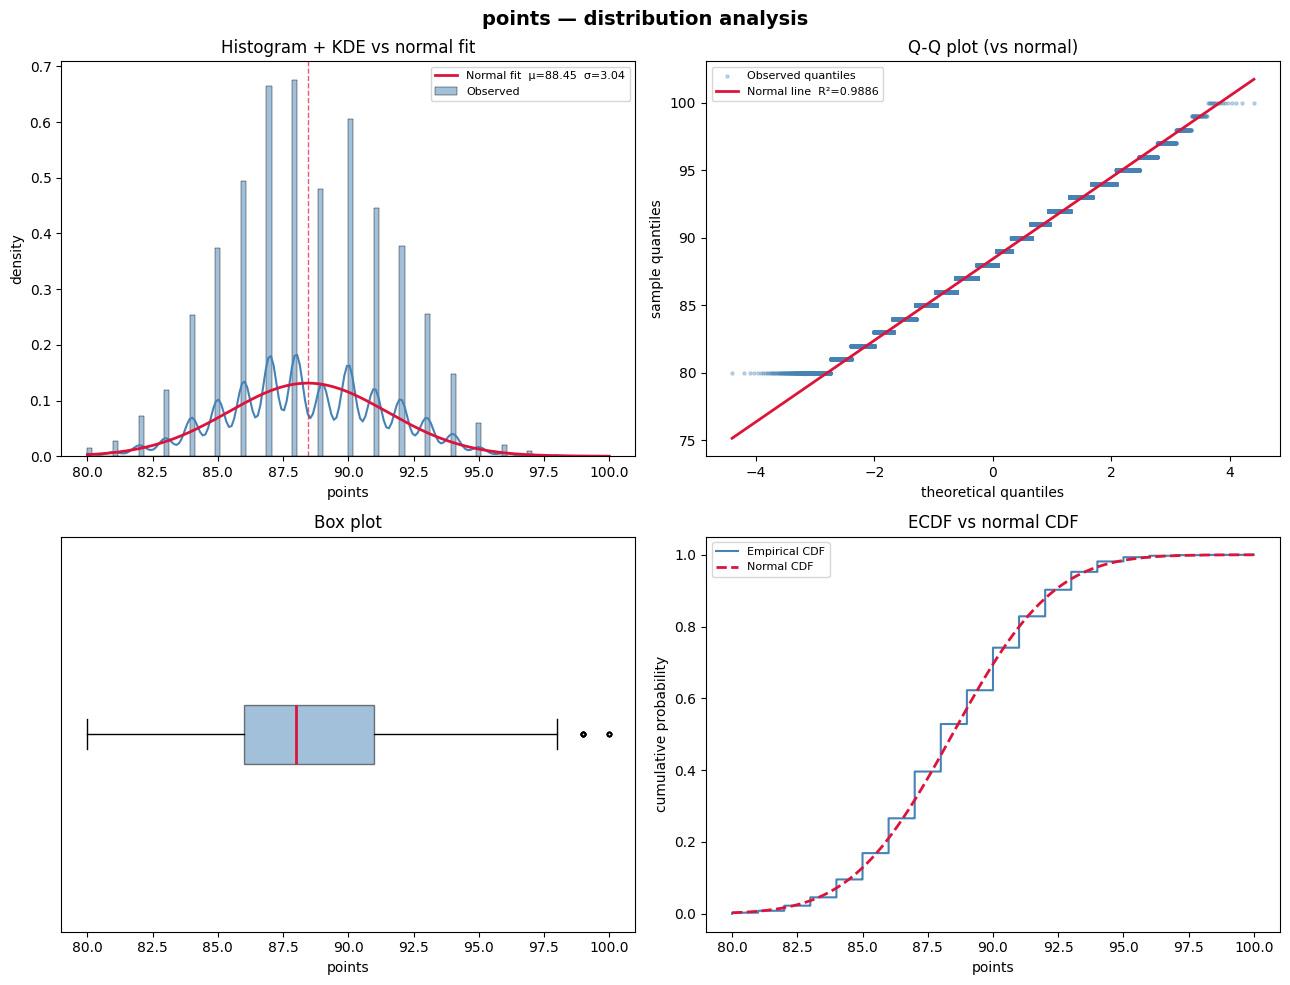

In [21]:
points = df["points"].dropna()

mu = points.mean()
sdev = points.std()
skew = stats.skew(points)
kurt = stats.kurtosis(points)

print("=== points — moments ===")
print(f"  Mean:     {mu:.4f}")
print(f"  SDEV:     {sdev:.4f}")
print(f"  Skewness: {skew:.4f}")
print(f"  Kurtosis: {kurt:.4f}  (excess; normal = 0)")

x = np.linspace(points.min(), points.max(), 300)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("points — distribution analysis", fontsize=14, fontweight="bold")

# 1. Histogram + KDE + normal fit
ax = axes[0, 0]
sns.histplot(
    points, stat="density", kde=True, ax=ax, color="steelblue", alpha=0.5, label="Observed"
)
ax.plot(
    x,
    stats.norm.pdf(x, mu, sdev),
    color="crimson",
    lw=2,
    label=f"Normal fit  μ={mu:.2f}  σ={sdev:.2f}",
)
ax.axvline(mu, color="crimson", lw=1, linestyle="--", alpha=0.7)
ax.set_title("Histogram + KDE vs normal fit")
ax.set_xlabel("points")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 2. Q-Q plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(points, dist="norm")
ax.scatter(osm, osr, s=5, alpha=0.3, color="steelblue", label="Observed quantiles")
ax.plot(
    osm,
    slope * np.array(osm) + intercept,
    color="crimson",
    lw=2,
    label=f"Normal line  R²={r**2:.4f}",
)
ax.set_title("Q-Q plot (vs normal)")
ax.set_xlabel("theoretical quantiles")
ax.set_ylabel("sample quantiles")
ax.legend(fontsize=8)

# 3. Box plot
ax = axes[1, 0]
ax.boxplot(
    points,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="crimson", lw=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
ax.set_title("Box plot")
ax.set_xlabel("points")
ax.set_yticks([])

# 4. ECDF vs theoretical normal CDF
ax = axes[1, 1]
ecdf_x = np.sort(points)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)
ax.step(ecdf_x, ecdf_y, color="steelblue", lw=1.5, label="Empirical CDF")
ax.plot(x, stats.norm.cdf(x, mu, sdev), color="crimson", lw=2, linestyle="--", label="Normal CDF")
ax.set_title("ECDF vs normal CDF")
ax.set_xlabel("points")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

=== price — moments (raw) ===
  Mean:     35.3634
  SDEV:     41.0222
  Skewness: 18.0007
  Kurtosis: 829.4858  (excess; normal = 0)
  Median:   25.0000   IQR: 25.0000

=== price — moments (log1p) ===
  Mean:     3.3573
  SDEV:     0.6311
  Skewness: 0.6570
  Kurtosis: 0.8645  (excess; normal = 0)


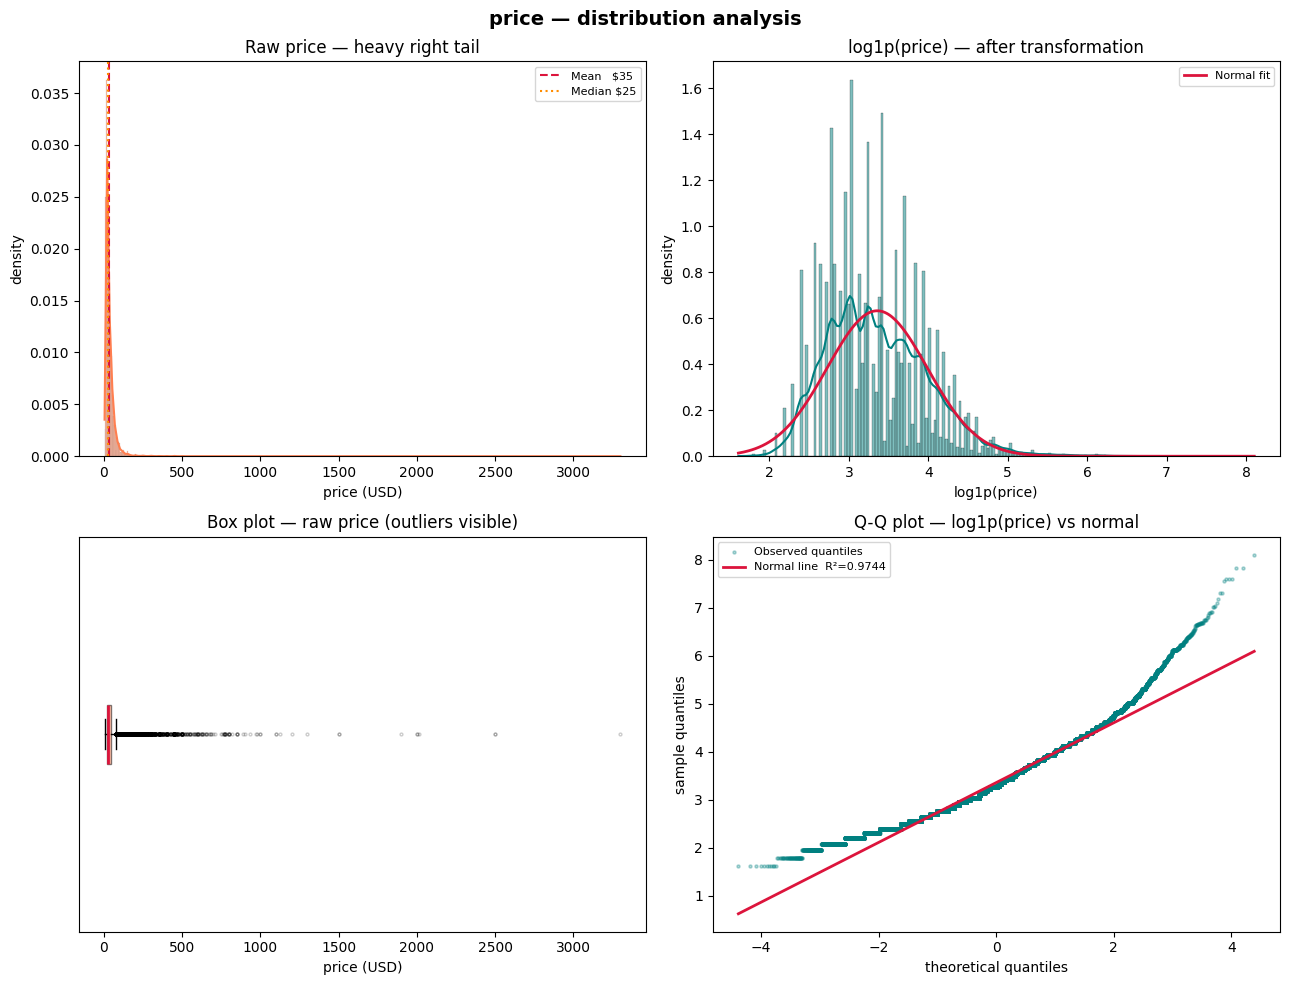

In [22]:
price = df["price"].dropna()
log_price = np.log1p(price)

mu_p = price.mean()
sdev_p = price.std()
skew_p = stats.skew(price)
kurt_p = stats.kurtosis(price)

print("=== price — moments (raw) ===")
print(f"  Mean:     {mu_p:.4f}")
print(f"  SDEV:     {sdev_p:.4f}")
print(f"  Skewness: {skew_p:.4f}")
print(f"  Kurtosis: {kurt_p:.4f}  (excess; normal = 0)")
print(f"  Median:   {price.median():.4f}   IQR: {price.quantile(0.75) - price.quantile(0.25):.4f}")

print("\n=== price — moments (log1p) ===")
print(f"  Mean:     {log_price.mean():.4f}")
print(f"  SDEV:     {log_price.std():.4f}")
print(f"  Skewness: {stats.skew(log_price):.4f}")
print(f"  Kurtosis: {stats.kurtosis(log_price):.4f}  (excess; normal = 0)")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("price — distribution analysis", fontsize=14, fontweight="bold")

# 1. Raw histogram + KDE
ax = axes[0, 0]
sns.histplot(price, stat="density", kde=True, ax=ax, color="coral", alpha=0.5)
ax.axvline(mu_p, color="crimson", lw=1.5, linestyle="--", label=f"Mean   ${mu_p:.0f}")
ax.axvline(
    price.median(), color="darkorange", lw=1.5, linestyle=":", label=f"Median ${price.median():.0f}"
)
ax.set_title("Raw price — heavy right tail")
ax.set_xlabel("price (USD)")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 2. log1p histogram + KDE
ax = axes[0, 1]
sns.histplot(log_price, stat="density", kde=True, ax=ax, color="teal", alpha=0.5)
mu_log = log_price.mean()
x_log = np.linspace(log_price.min(), log_price.max(), 300)
ax.plot(
    x_log, stats.norm.pdf(x_log, mu_log, log_price.std()), color="crimson", lw=2, label="Normal fit"
)
ax.set_title("log1p(price) — after transformation")
ax.set_xlabel("log1p(price)")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# 3. Box plot (raw) — outliers visible
ax = axes[1, 0]
ax.boxplot(
    price,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="coral", alpha=0.5),
    medianprops=dict(color="crimson", lw=2),
    flierprops=dict(marker="o", markersize=2, alpha=0.2, color="darkorange"),
)
ax.set_title("Box plot — raw price (outliers visible)")
ax.set_xlabel("price (USD)")
ax.set_yticks([])

# 4. Q-Q plot (log1p)
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(log_price, dist="norm")
ax.scatter(osm, osr, s=5, alpha=0.3, color="teal", label="Observed quantiles")
ax.plot(
    osm,
    slope * np.array(osm) + intercept,
    color="crimson",
    lw=2,
    label=f"Normal line  R²={r**2:.4f}",
)
ax.set_title("Q-Q plot — log1p(price) vs normal")
ax.set_xlabel("theoretical quantiles")
ax.set_ylabel("sample quantiles")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Conclusions

### Dataset overview

The dataset contains **129,971 wine reviews** across 13 columns with no exact duplicate rows. Overall, 12.1% of cells are missing, distributed unevenly across 9 of the 13 columns.

---

### Target variable — `points`

The score assigned by tasters ranges from 80 to 100 with a mean of **88.45** and standard deviation of **3.04**. The distribution is nearly symmetric (skewness 0.05), which supports framing this as a **regression problem**. The narrow range and low variance suggest that small differences in predicted score are meaningful.

---

### Missing values

| Column | Missing |
|---|---|
| `region_2` | 61.1% |
| `designation` | 28.8% |
| `taster_twitter_handle` | 24.0% |
| `taster_name` | 20.2% |
| `region_1` | 16.3% |
| `price` | 6.9% |
| `country` / `province` | < 0.1% |
| `variety` | < 0.01% |

`region_2` is critically sparse and unlikely to contribute reliable signal. `taster_twitter_handle` is redundant with `taster_name`. The remaining missing columns will require deliberate imputation or flag encoding in preprocessing.

---

### `price` — extreme skew

`price` has a skewness of **18.0** with values ranging from $4 to $3,300 and a mean of $35.36. The distribution is heavily dominated by outliers at the high end. A log transformation will be necessary before any model can use this feature effectively.

---

### Categorical cardinality

| Column | Unique values |
|---|---|
| `winery` | 16,757 |
| `variety` | 707 |
| `province` | 425 |
| `country` | 43 |
| `taster_name` | 19 |

`winery` and `variety` have high cardinality that rules out one-hot encoding. Target encoding or frequency encoding will be required. `taster_name` (19 values) is low enough for direct encoding and is worth preserving given that tasters have measurable scoring biases.

---

### Text columns

`description` (109,945 near-unique values) and `title` (108,104 near-unique values) are not usable as raw tabular features. `title` encodes the vintage year, which can be extracted via regex. `description` can be transformed into dense semantic embeddings via a pre-trained language model (BERT) for use in the neural network.